In [32]:
%cd /content/ai-gnn-gdelt-sp500
!git branch
!git log --oneline -5
!grep -n "construir_aristas_mc" src/datos/grafo.py

!git fetch origin
!git checkout Hotfix

/content/ai-gnn-gdelt-sp500
* main
8d9bf97 (HEAD -> main, origin/main, origin/HEAD) Metrics + fix
1ce4771 New metrics
19e1245 Fixes
93820b8 Uso folds arreglado
49438d0 Metricas visuales
Branch 'Hotfix' set up to track remote branch 'Hotfix' from 'origin'.
Switched to a new branch 'Hotfix'


In [33]:
!git branch
!grep -n "construir_aristas_mc" src/datos/grafo.py

* Hotfix
  main
315:def construir_aristas_mc() -> tuple[torch.Tensor, torch.Tensor]:
402:    ei_mc, ea_mc = construir_aristas_mc()


# TFM · GNN × GDELT × SP500

Orquestador de entrenamiento. Este notebook ejecuta el pipeline de extremo a extremo:

1. Clonar el repo y instalar dependencias.
2. Descargar datos de GDELT y financieros.
3. Preprocesar y construir el dataset.
4. Entrenar la HGNN con walk-forward.
5. Evaluar y comparar con baselines.

Editar los parámetros de `config.py` (en el repo) para ajustar el experimento. No conviene poner lógica nueva en este notebook: si algo se reusa, va a `src/`.

## 1. Setup

En la primera ejecución en Colab hay que clonar el repo e instalar PyG. PyTorch Geometric requiere instalación específica según la versión de torch+CUDA de Colab.

In [1]:
# Detectar si estamos en Colab
try:
    import google.colab  # type: ignore
    EN_COLAB = True
except ImportError:
    EN_COLAB = False
print('En Colab:', EN_COLAB)

En Colab: True


In [2]:
if EN_COLAB:
    # AJUSTAR: reemplazar <usuario> por vuestro usuario de GitHub
    # Si el repo es privado, guardar el token en los secrets de Colab y descomentar las dos líneas siguientes:
    # from google.colab import userdata
    # token = userdata.get('GITHUB_TOKEN')
    # !git clone https://{token}@github.com/<usuario>/ai-gnn-gdelt-sp500.git
    !git clone https://github.com/ricardmartin/ai-gnn-gdelt-sp500.git
    %cd ai-gnn-gdelt-sp500
    !pip install -q -r requirements.txt

fatal: destination path 'ai-gnn-gdelt-sp500' already exists and is not an empty directory.
/content/ai-gnn-gdelt-sp500
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [3]:
import sys
from pathlib import Path
# Asegurar que el cwd está en el repo (importar src.* requiere esto)
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

## 2. Descarga de datos

Definir el rango de fechas y descargar GDELT + SP500. Ajustar en `config.py` o sobreescribir aquí.

In [4]:
from datetime import date
import config
from src.datos.descarga_gdelt import descargar_rango
from src.datos.descarga_financiero import descargar_sp500, descargar_vix, descargar_macro_fred

config.FECHA_INICIO = "2018-01-01"
config.FECHA_FIN = "2021-12-31"

FECHA_INI = date.fromisoformat(config.FECHA_INICIO)
FECHA_FIN = date.fromisoformat(config.FECHA_FIN)

rutas_gdelt = descargar_rango(FECHA_INI, FECHA_FIN)
print(f'GDELT: {len(rutas_gdelt)} días descargados')

GDELT: 1461 días descargados


In [5]:
precios = descargar_sp500(FECHA_INI, FECHA_FIN)
vix = descargar_vix(FECHA_INI, FECHA_FIN)
try:
    macro = descargar_macro_fred(FECHA_INI, FECHA_FIN)
except Exception as e:
    print('Macro FRED no disponible:', e)
    macro = None

print('SP500:', len(precios), 'sesiones')
print('VIX:', len(vix), 'puntos')

SP500: 1007 sesiones
VIX: 1007 puntos


## 3. Preprocesado y construcción del dataset

In [6]:
from pathlib import Path
from src.datos.preprocesar import (
    preprocesar_y_agregar_por_tramos,
    cargar_agregados_de_disco,
)

# Carpeta donde se guardan los agregados ya procesados. Apuntala a tu Drive
# para que sobrevivan a desconexiones de Colab, por ejemplo:
# DIR_AGREGADOS = Path("/content/drive/MyDrive/TFM/agregados")
DIR_AGREGADOS = Path("data/agregados")

# Procesa GDELT POR TRAMOS: el pico de RAM es el de un tramo, no el del rango
# completo. Es resumible: si Colab se corta, vuelve a ejecutar y sigue donde iba.
# Baja dias_por_tramo si aun vas justo de RAM (p.ej. 90); subelo si te sobra.
preprocesar_y_agregar_por_tramos(rutas_gdelt, DIR_AGREGADOS, dias_por_tramo=180)

# Carga el "concentrado" (pequeno) desde disco. Ya NO se mantiene df_eventos
# entero en memoria.
df_agregado, df_participacion = cargar_agregados_de_disco(DIR_AGREGADOS)
print("Aristas agregadas:", len(df_agregado))
print("Filas de participacion (nodo):", len(df_participacion))


Aristas agregadas: 849762
Filas de participacion (nodo): 369581


In [7]:
from src.datos.etiquetas import construir_etiquetas_diarias

etiquetas = construir_etiquetas_diarias(precios)
print(etiquetas.head())
print('Distribución de clases:')
print(etiquetas['clase'].value_counts().sort_index())

  fecha_target   retorno  clase fecha_grafo
0   2018-01-03  0.006399      1  2018-01-02
1   2018-01-04  0.004029      1  2018-01-03
2   2018-01-05  0.007034      2  2018-01-04
3   2018-01-08  0.001662      1  2018-01-05
4   2018-01-09  0.001303      1  2018-01-08
Distribución de clases:
clase
0    176
1    573
2    257
Name: count, dtype: int64


In [8]:
from src.datos.preprocesar import (
    preprocesar_y_agregar_por_tramos,
    cargar_agregados_de_disco,
)
from src.datos.etiquetas import construir_etiquetas_diarias
from src.datos.dataset import DatasetGrafoDiario

In [9]:
# Filtrar etiquetas a fechas para las que tenemos datos de GDELT
import pandas as pd
from src.datos.dataset import DatasetGrafoDiario

fechas_gdelt = set(pd.to_datetime(df_agregado['fecha']).dt.normalize().unique())
etiquetas_validas = etiquetas[pd.to_datetime(etiquetas['fecha_grafo']).dt.normalize().isin(fechas_gdelt)].reset_index(drop=True)
print(f'Etiquetas alineadas: {len(etiquetas_validas)}/{len(etiquetas)}')

dataset = DatasetGrafoDiario(
    eventos_agregados=df_agregado,
    etiquetas=etiquetas_validas,
    precios_sp500=precios,
    macro=macro,
    vix=vix,
    participacion=df_participacion,
    precomputar=False,
)
print('Dataset:', len(dataset), 'muestras')

Etiquetas alineadas: 1006/1006
Dataset: 1006 muestras


## 4. Walk-forward + entrenamiento

In [10]:
import torch
from src.entrenamiento.walkforward import construir_folds
from src.entrenamiento.loop import entrenar_walkforward

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', dispositivo)

# Folds medidos en MUESTRAS (sesiones), no en días de calendario.
# Con tam_val/train_inicial = None, el rango se parte en (num_folds + 1)
# bloques iguales y la validacion cubre toda la cola del periodo.
folds = construir_folds(
    fechas=etiquetas_validas['fecha_grafo'],
    num_folds=5,
    # tam_val_muestras=None,        # None -> se deriva de N
    # train_inicial_muestras=None,  # None -> se deriva de N
    # embargo=0,                    # pon 1 para un dia de hueco anti-leakage
)
print(f'{len(folds)} folds construidos')
for f in folds:
    print(f'  Fold {f.fold_id}: '
          f'train {f.fecha_train_inicio.date()}..{f.fecha_train_fin.date()} n={len(f.idx_train)} | '
          f'val {f.fecha_val_inicio.date()}..{f.fecha_val_fin.date()} n={len(f.idx_val)}')

Dispositivo: cpu
5 folds construidos
  Fold 0: train 2018-01-02..2018-08-29 n=167 | val 2018-08-30..2019-05-01 n=167
  Fold 1: train 2018-01-02..2019-05-01 n=334 | val 2019-05-02..2019-12-27 n=167
  Fold 2: train 2018-01-02..2019-12-27 n=501 | val 2019-12-30..2020-08-26 n=167
  Fold 3: train 2018-01-02..2020-08-26 n=668 | val 2020-08-27..2021-04-27 n=167
  Fold 4: train 2018-01-02..2021-04-27 n=835 | val 2021-04-28..2021-12-22 n=167


In [11]:
retornos_por_indice = etiquetas_validas['retorno'].values

resultado = entrenar_walkforward(
    dataset=dataset,
    folds=folds,
    semillas=(0, 1, 2),
    dispositivo=dispositivo,
    retornos_por_indice=retornos_por_indice,
)
print(resultado.resumen_final())

folds=15 | accuracy = 0.5533 ± 0.1125 | f1_macro = 0.4280 ± 0.0725 | rent_estrategia = +8.36% ± 7.53% | rent_buy_hold = +10.43% ± 6.35% | vs_BH = -2.08pp ± 4.95pp | sharpe = 1.08 ± 0.93 | maxDD = -11.33% ± 8.90%


In [12]:
import numpy as np
from IPython.display import HTML, display

def mostrar_resultados(resultado):
    ms = resultado.media_y_std()
    n_folds = len(resultado.metricas_por_fold)

    def mstd(k, pct=False, pp=False, signo=False):
        if k not in ms: return "—"
        m, s = ms[k]
        if pct:  return (f"{100*m:+.2f}% ± {100*s:.2f}%") if signo else (f"{100*m:.2f}% ± {100*s:.2f}%")
        if pp:   return f"{100*m:+.2f} pp ± {100*s:.2f} pp"
        return f"{m:.4f} ± {s:.4f}"

    f1c = np.mean([m.f1_por_clase for m in resultado.metricas_por_fold], axis=0)
    f1c_txt = " · ".join(f"{n}: {v:.3f}" for n, v in zip(["Baja","Neutro","Sube"], f1c))

    filas = [
        ("Accuracy", mstd("accuracy"),
         "Proporción de días en que acierta la dirección. Con clases desbalanceadas puede engañar."),
        ("F1-macro", mstd("f1_macro"),
         "Media del F1 de las 3 clases tratándolas por igual. Es la métrica principal del trabajo."),
        ("F1 por clase", f1c_txt,
         "F1 de cada clase por separado: revela si el modelo falla en alguna dirección concreta."),
    ]
    if "sharpe" in ms:
        filas += [
            ("Rent. estrategia", mstd("rent_estrategia", pct=True, signo=True),
             "Lo que habrías ganado/perdido siguiendo las señales del modelo."),
            ("Rent. buy & hold", mstd("rent_buy_hold", pct=True, signo=True),
             "Lo que habrías ganado comprando y manteniendo el índice. Es la referencia a batir."),
            ("vs Buy & Hold", mstd("rent_vs_bh", pp=True),
             "Diferencia frente a comprar y mantener. Positivo = el modelo aporta valor."),
            ("Sharpe", mstd("sharpe"),
             "Rentabilidad ajustada por riesgo (retorno por unidad de volatilidad). Más alto, mejor."),
            ("Máx. drawdown", mstd("max_drawdown", pct=True),
             "La peor caída desde un máximo a un mínimo. Mide el peor mal trago de la estrategia."),
        ]

    filas_html = "".join(
        f"<tr style='border-bottom:1px solid #ddd'>"
        f"<td style='padding:6px 12px;font-weight:600;white-space:nowrap;color:#111'>{n}</td>"
        f"<td style='padding:6px 12px;font-family:monospace;font-weight:600;color:#0b5fa5;white-space:nowrap'>{v}</td>"
        f"<td style='padding:6px 12px;color:#333;font-size:0.9em'>{d}</td></tr>"
        for n, v, d in filas
    )

    cm = sum(m.matriz_confusion for m in resultado.metricas_por_fold)
    clases = ["Baja","Neutro","Sube"]
    cab = "".join(f"<th style='padding:4px 10px;color:#111'>{c}</th>" for c in clases)
    cuerpo = ""
    for i, c in enumerate(clases):
        celdas = "".join(
            f"<td style='padding:4px 10px;text-align:center;color:#111;"
            f"background:{'#b7e1c1' if i==j else '#f2f2f2'}'>{int(cm[i][j])}</td>"
            for j in range(3))
        cuerpo += f"<tr><th style='padding:4px 10px;text-align:right;color:#111'>{c}</th>{celdas}</tr>"

    html = f"""
    <div style='font-family:system-ui,sans-serif;max-width:760px;background:#ffffff;
                padding:16px 20px;border-radius:8px;border:1px solid #ccc'>
      <h3 style='margin:0 0 2px;color:#111'>Resultados del modelo GNN geopolítico</h3>
      <p style='color:#555;margin:0 0 10px'>Media ± desviación típica sobre {n_folds} folds (walk-forward, varias semillas)</p>
      <table style='border-collapse:collapse;width:100%'>{filas_html}</table>
      <p style='margin:14px 0 4px;font-weight:600;color:#111'>Matriz de confusión (filas = realidad, columnas = predicho)</p>
      <table style='border-collapse:collapse'>
        <tr><th></th>{cab}</tr>{cuerpo}
      </table>
      <p style='color:#666;font-size:0.82em;margin-top:6px'>La diagonal (en verde) son los aciertos. Fuera de la diagonal, los errores.</p>
    </div>"""
    display(HTML(html))

mostrar_resultados(resultado)

## 5. Baselines

Comparación con modelos clásicos para aislar la aportación de la GNN.

In [13]:
from src.modelo.baselines import (
    BaselineNaive, construir_matriz_features,
    entrenar_logistica, entrenar_xgboost,
)
from src.datos.etiquetas import clases_para_fold
from src.entrenamiento.evaluacion import calcular_metricas

# Construir X aplanado desde el dataset entero.
X, _y_provisional = construir_matriz_features(dataset)
print('X shape:', X.shape)

# Usar el primer fold como referencia rápida.
# IMPORTANTE (anti-leakage): las etiquetas del fold se calculan con umbrales
# derivados SOLO del train de ese fold, exactamente igual que hace la HGNN.
# Así todos los modelos compiten con las mismas etiquetas.
f0 = folds[0]
y_fold, umbrales_f0 = clases_para_fold(retornos_por_indice, f0.idx_train)
print('Umbrales del fold 0:', umbrales_f0.resumen())

X_tr, y_tr = X[f0.idx_train], y_fold[f0.idx_train]
X_va, y_va = X[f0.idx_val], y_fold[f0.idx_val]

naive = BaselineNaive().fit(X_tr, y_tr)
logr = entrenar_logistica(X_tr, y_tr)
xgb = entrenar_xgboost(X_tr, y_tr)

for nombre, modelo in [('naive', naive), ('logística', logr), ('xgboost', xgb)]:
    m = calcular_metricas(y_va, modelo.predict(X_va))
    print(f'{nombre:>10s}: {m.resumen()}')


X shape: (1006, 45) | y shape: (1006,)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


     naive: acc=0.6287 | F1_macro=0.2574 | F1_clases=[0.0, 0.772, 0.0] | n=167
 logística: acc=0.3293 | F1_macro=0.2926 | F1_clases=[0.073, 0.443, 0.362] | n=167
   xgboost: acc=0.6048 | F1_macro=0.3482 | F1_clases=[0.0, 0.763, 0.281] | n=167


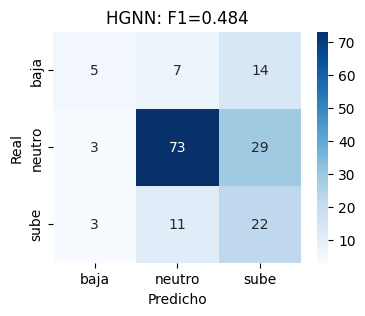

In [14]:
import numpy as np
import torch
from torch_geometric.loader import DataLoader
from src.modelo.arquitectura import HGNNGeopolitica
from src.entrenamiento.loop import entrenar_un_fold
from src.entrenamiento.evaluacion import calcular_metricas
import seaborn as sns
import matplotlib.pyplot as plt

# Entrenar la HGNN en el primer fold y guardar predicciones.
# `retornos_por_indice` activa el protocolo correcto: etiquetas con umbral
# solo del train del fold, early stopping con validación interna y
# normalización de features con estadísticas solo del train interno.
f0 = folds[0]
m, hist, *_ = entrenar_un_fold(dataset, f0.idx_train, f0.idx_val,
                            seed=0, dispositivo=dispositivo, verbose=False,
                            retornos_por_indice=retornos_por_indice)

# Pintar la matriz de confusión de la HGNN (evaluada UNA vez sobre el test)
plt.figure(figsize=(4, 3))
sns.heatmap(m.matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['baja', 'neutro', 'sube'],
            yticklabels=['baja', 'neutro', 'sube'])
plt.title(f'HGNN: F1={m.f1_macro:.3f}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()


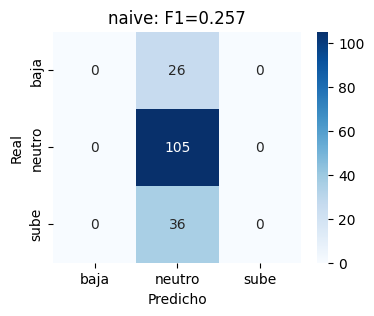

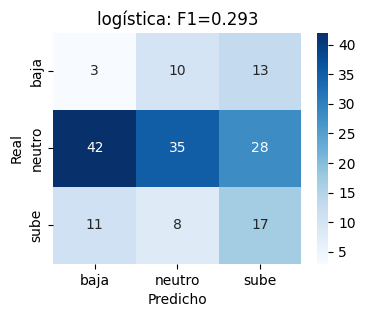

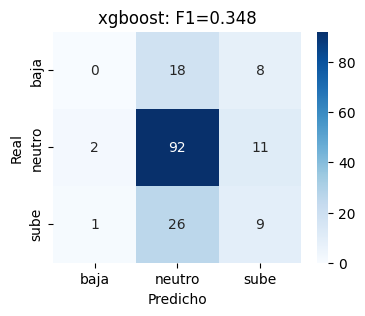

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from src.entrenamiento.evaluacion import calcular_metricas

# Para cada modelo
for nombre, modelo in [('naive', naive), ('logística', logr), ('xgboost', xgb)]:
    m = calcular_metricas(y_va, modelo.predict(X_va))
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        m.matriz_confusion,
        annot=True, fmt='d', cmap='Blues',
        xticklabels=['baja', 'neutro', 'sube'],
        yticklabels=['baja', 'neutro', 'sube'],
    )
    plt.title(f'{nombre}: F1={m.f1_macro:.3f}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

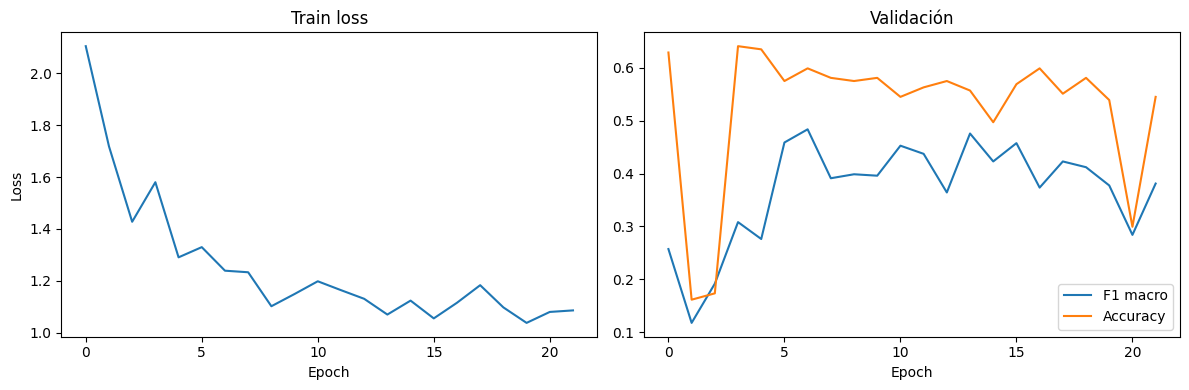

In [16]:
from src.entrenamiento.loop import entrenar_un_fold
import matplotlib.pyplot as plt

f0 = folds[0]
m, hist, *_ = entrenar_un_fold(
    dataset, f0.idx_train, f0.idx_val,
    seed=0, dispositivo=dispositivo, verbose=True,
    retornos_por_indice=retornos_por_indice,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist['train_loss'])
axes[0].set_title('Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# OJO: estas curvas son de la validación INTERNA (el tramo final del train),
# que es la que decide el early stopping. El test del fold solo se evalúa
# una vez al final y no aparece aquí.
axes[1].plot(hist['val_f1'], label='F1 macro (val interna)')
axes[1].plot(hist['val_acc'], label='Accuracy (val interna)')
axes[1].set_title('Validación interna')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


In [17]:
data, clase = dataset[0]
print('Clase real:', clase)
print('Grafo:', data)
print()
print('Features del market:', data['market'].x)
print('Features de los países (primeras filas):')
print(data['country'].x[:5])
print()
print('Aristas país↔país:', data['country', 'interactua', 'country'].edge_index.shape[1])
print('Aristas país→market:', data['country', 'expone', 'market'].edge_index.shape[1])
print('Aristas market→país:', data['market', 'influye', 'country'].edge_index.shape[1])

Clase real: 1
Grafo: HeteroData(
  country={ x=[20, 11] },
  market={
    x=[1, 9],
    y=[1],
  },
  (country, interactua, country)={
    edge_index=[2, 807],
    edge_attr=[807, 7],
  },
  (country, expone, market)={
    edge_index=[2, 20],
    edge_attr=[20, 1],
  },
  (market, influye, country)={
    edge_index=[2, 20],
    edge_attr=[20, 1],
  }
)

Features del market: tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, 21.9463,  9.7700,  0.0000,  1.4200,
          2.4600]])
Features de los países (primeras filas):
tensor([[-2.8295e+00, -5.5691e-01,  9.5672e+00,  1.3078e+01,  1.0000e+00,
          9.3764e+00,  9.7581e+00,  2.5488e-01,  2.5195e-01,  2.4162e-01,
          2.5155e-01],
        [-1.3827e+00,  3.7277e-01,  7.3484e+00,  1.0103e+01,  1.6000e-01,
          7.2089e+00,  7.4878e+00,  3.4252e-01,  2.6382e-01,  1.8524e-01,
          2.0842e-01],
        [-2.3923e+00, -4.6620e-02,  6.8972e+00,  9.9272e+00,  5.0000e-03,
          6.8298e+00,  6.9645e+00,  3.8532e-01,  2.4410e-01,  1.9

In [18]:
import src.datos.grafo as g
print("influye" in open(g.__file__).read())

True


In [19]:
%cd /content/ai-gnn-gdelt-sp500
!git branch

/content/ai-gnn-gdelt-sp500
* Hotfix
  main


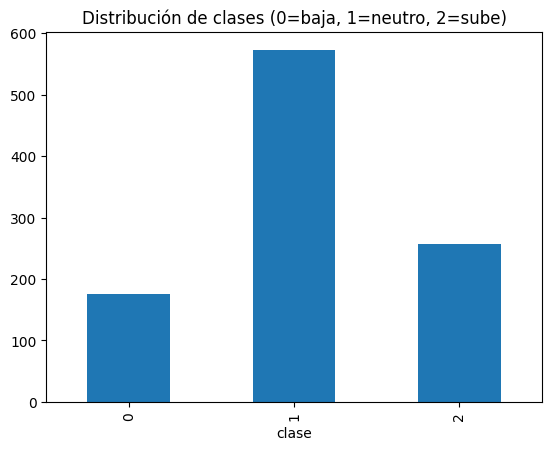

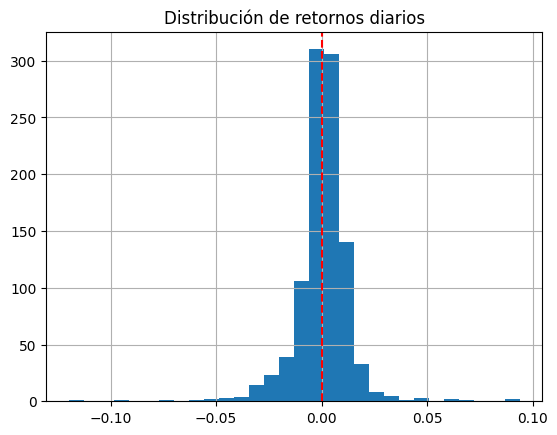

In [20]:
import matplotlib.pyplot as plt

# Distribución de clases en todo el dataset
etiquetas_validas['clase'].value_counts().sort_index().plot(
    kind='bar',
    title='Distribución de clases (0=baja, 1=neutro, 2=sube)',
)
plt.show()

# Distribución de retornos
etiquetas_validas['retorno'].hist(bins=30)
plt.title('Distribución de retornos diarios')
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [21]:
# Día con más eventos
fecha_max = df_agregado.groupby('fecha')['n_eventos'].sum().idxmax()
print(f'Día más activo: {fecha_max}')

df_agregado[df_agregado['fecha'] == fecha_max].sort_values('n_eventos', ascending=False).head(15)

Día más activo: 2018-05-09 00:00:00


,fecha,pais_origen,pais_destino,quadclass,n_eventos,goldstein_medio,tono_medio,num_mentions_total
87523,2018-05-09,USA,USA,1,1210,2.258678,-1.190216,38642
87526,2018-05-09,USA,USA,4,362,-7.618232,-4.988551,12505
87353,2018-05-09,PRK,USA,1,358,2.615922,-1.040254,45792
87524,2018-05-09,USA,USA,2,353,5.753541,-1.749799,16989
87504,2018-05-09,USA,PRK,1,346,2.721387,-0.624602,42135
87525,2018-05-09,USA,USA,3,291,-3.123024,-3.873433,9245
87484,2018-05-09,USA,IRN,1,286,3.141259,-2.174334,9369
87485,2018-05-09,USA,IRN,2,241,8.803320,-2.491308,12203
87249,2018-05-09,JPN,CHN,1,220,3.323636,0.565449,13114
87207,2018-05-09,IRN,USA,1,207,3.049758,-2.290426,8029


In [22]:
!pip install -q pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.9 MB/s eta 0:00:00


In [23]:
import matplotlib.pyplot as plt
import numpy as np
from pyvis.network import Network
from google.colab import files
from src.utils.paises import ROSTER, INDICE_A_PAIS

def visualizar_grafo_limpio(data, fecha=None, top_aristas_cc=15, archivo='grafo.html'):
    """
    Grafo limpio:
    - Aristas país↔país agrupadas (suma de las QuadClass entre cada par)
    - Solo top N por peso
    - Color según predominio cooperación/conflicto
    - Aristas país→SP500 con grosor según comercio, normalizado
    """
    net = Network(height='800px', width='100%', directed=True,
                  notebook=False, cdn_resources='in_line', bgcolor='#ffffff')

    # ----- Agrupar aristas país↔país por par (origen, destino) -----
    ei_cc = data['country', 'interactua', 'country'].edge_index.cpu().numpy()
    ea_cc = data['country', 'interactua', 'country'].edge_attr.cpu().numpy()

    agrupado = {}
    for k in range(ei_cc.shape[1]):
        o, d = int(ei_cc[0, k]), int(ei_cc[1, k])
        peso = float(ea_cc[k, 0])
        quad = int(ea_cc[k, 3:7].argmax())
        es_conflicto = quad >= 2

        key = (o, d)
        if key not in agrupado:
            agrupado[key] = {'peso': 0.0, 'coop': 0.0, 'conf': 0.0}
        agrupado[key]['peso'] += peso
        if es_conflicto:
            agrupado[key]['conf'] += peso
        else:
            agrupado[key]['coop'] += peso

    pares_ordenados = sorted(agrupado.items(), key=lambda x: x[1]['peso'], reverse=True)
    top_pares = pares_ordenados[:top_aristas_cc]

    # ----- Países que aparecen en las top aristas o con comercio relevante -----
    paises_activos = set()
    for (o, d), _ in top_pares:
        paises_activos.add(o)
        paises_activos.add(d)

    ei_cm = data['country', 'expone', 'market'].edge_index.cpu().numpy()
    ea_cm = data['country', 'expone', 'market'].edge_attr.cpu().numpy()
    for j in range(ei_cm.shape[1]):
        if float(ea_cm[j, 0]) > 0.05:
            paises_activos.add(int(ei_cm[0, j]))

    # ----- Añadir nodos país -----
    for i in paises_activos:
        p = ROSTER[i]
        feats = data['country'].x[i].tolist()
        tono = float(feats[0])
        goldstein = float(feats[1])
        if goldstein < -1:
            color = '#ff8787'
        elif goldstein > 1:
            color = '#8ce99a'
        else:
            color = '#a5d8ff'
        titulo = (f"<b>{p.nombre}</b><br>"
                  f"Tono: {tono:.2f}<br>"
                  f"Goldstein: {goldstein:.2f}")
        net.add_node(p.id, label=p.id, title=titulo,
                     color=color, size=22, font={'size': 14, 'face': 'arial'})

    # ----- Nodo SP500 -----
    sp = data['market'].x[0].tolist()
    titulo_sp = (f"<b>S&P 500</b><br>"
                 f"Retorno 1d: {float(sp[0]):.4f}<br>"
                 f"Volatilidad 21d: {float(sp[3]):.4f}")
    net.add_node('SP500', label='SP500', title=titulo_sp,
                 color='#ffd43b', size=38, shape='diamond',
                 font={'size': 16, 'face': 'arial'})

    # ----- Aristas país↔país (top N agrupadas) -----
    pesos_top = np.array([v['peso'] for _, v in top_pares])
    peso_max = float(pesos_top.max()) if len(pesos_top) else 1.0

    for (o, d), v in top_pares:
        origen_id = INDICE_A_PAIS[o]
        destino_id = INDICE_A_PAIS[d]
        ancho = float(1.0 + 5.0 * (v['peso'] / peso_max))
        if v['conf'] > v['coop'] * 1.2:
            color = '#e03131'
        elif v['coop'] > v['conf'] * 1.2:
            color = '#2f9e44'
        else:
            color = '#868e96'
        titulo = (f"{origen_id} → {destino_id}<br>"
                  f"Peso total: {float(v['peso']):.2f}<br>"
                  f"Cooperación: {float(v['coop']):.2f}<br>"
                  f"Conflicto: {float(v['conf']):.2f}")
        net.add_edge(origen_id, destino_id,
                     width=ancho, color=color,
                     title=titulo)

    # ----- Aristas país → SP500 -----
    pesos_cm = ea_cm[:, 0]
    peso_cm_max = float(pesos_cm.max()) if len(pesos_cm) else 1.0

    for j in range(ei_cm.shape[1]):
        idx_pais = int(ei_cm[0, j])
        if idx_pais not in paises_activos:
            continue
        peso = float(ea_cm[j, 0])
        if peso <= 0.05:
            continue
        origen_id = INDICE_A_PAIS[idx_pais]
        ancho = float(0.5 + 3.5 * (peso / peso_cm_max))
        net.add_edge(origen_id, 'SP500',
                     width=ancho, color='#ffa94d',
                     dashes=True,
                     title=f"Comercio {origen_id}↔USA: {peso:.3f}")

    # Opciones de layout
    net.set_options("""
    {
      "physics": {
        "forceAtlas2Based": {
          "gravitationalConstant": -80,
          "centralGravity": 0.01,
          "springLength": 150,
          "springConstant": 0.08
        },
        "solver": "forceAtlas2Based",
        "stabilization": {"iterations": 200}
      },
      "edges": {
        "arrows": {"to": {"enabled": true, "scaleFactor": 0.5}},
        "smooth": {"type": "curvedCW", "roundness": 0.15}
      },
      "interaction": {"hover": true}
    }
    """)

    html = net.generate_html(notebook=False)
    with open(archivo, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f"HTML generado: {archivo}")
    files.download(archivo)


data, clase = dataset[0]
fecha = etiquetas_validas.iloc[0]['fecha_grafo']
visualizar_grafo_limpio(data, fecha=fecha, top_aristas_cc=15)

HTML generado: grafo.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

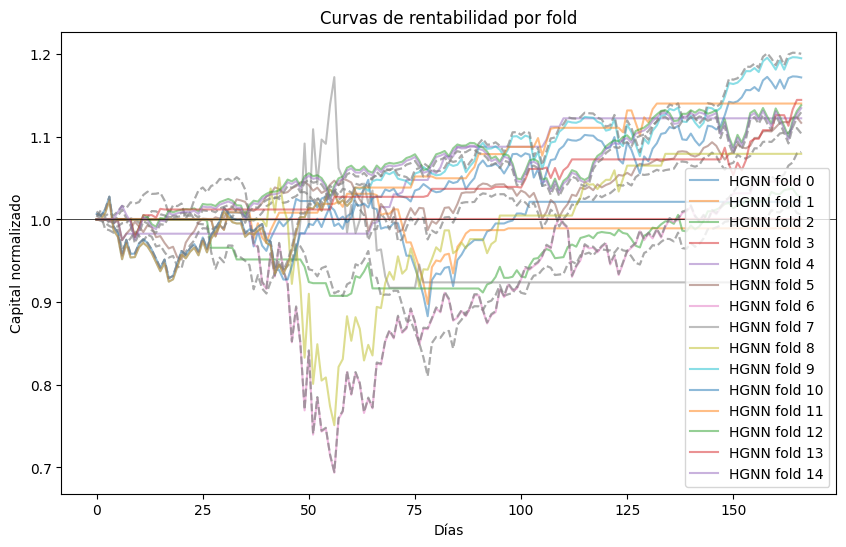

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for i, mf in enumerate(resultado.metricas_financieras_por_fold):
    plt.plot(mf.curva_estrategia, alpha=0.5, label=f'HGNN fold {i}')
    plt.plot(mf.curva_buy_hold, alpha=0.3, color='gray', linestyle='--')
plt.axhline(1.0, color='black', linewidth=0.5)
plt.ylabel('Capital normalizado')
plt.xlabel('Días')
plt.legend()
plt.title('Curvas de rentabilidad por fold')
plt.show()

In [25]:
import numpy as np, pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Concatenar crudos de todos los (fold, semilla). Todo es out-of-sample (validación).
probas = np.concatenate(resultado.probas_crudas, axis=0)
y_true = np.concatenate(resultado.reales_crudas, axis=0).astype(int)
retornos_test = np.concatenate(
    [r for r in resultado.retornos_crudos if r is not None], axis=0
).astype(float)
y_pred = probas.argmax(axis=1)
N = {0: "baja", 1: "neutro", 2: "sube"}
n = len(y_true)
print(f"n out-of-sample (folds × semillas) = {n}\n")

# [1] DISTRIBUCIÓN real vs predicha + baseline mayoritario
print("[1] DISTRIBUCIÓN real vs predicha")
for c in [0, 1, 2]:
    print(f"  {N[c]:6} real {(y_true==c).sum():5d} ({100*(y_true==c).mean():4.1f}%) | "
          f"pred {(y_pred==c).sum():5d} ({100*(y_pred==c).mean():4.1f}%)")
may = int(pd.Series(y_true).value_counts().idxmax())
acc_base = (y_true == may).mean()
acc_mod = (y_pred == y_true).mean()
print(f"  baseline 'siempre {N[may]}': acc={acc_base:.4f}")
print(f"  modelo:                 acc={acc_mod:.4f}  -> "
      f"{'SUPERA' if acc_mod>acc_base else 'NO supera'} ({acc_mod-acc_base:+.4f})")

# [2] CONFIANZA + CALIBRACIÓN
conf = probas.max(axis=1)
print(f"\n[2] CONFIANZA  media={conf.mean():.3f}  "
      f"plana(<0.40)={100*(conf<0.40).mean():.0f}%  confiada(>0.70)={100*(conf>0.70).mean():.0f}%")
print("    calibración (si dice conf X, ¿acierta X?):")
for lo, hi in [(0.33,0.40),(0.40,0.50),(0.50,0.60),(0.60,0.70),(0.70,1.01)]:
    m = (conf >= lo) & (conf < hi)
    if m.sum():
        print(f"      [{lo:.2f},{hi:.2f}) n={m.sum():5d} acc_real={(y_pred[m]==y_true[m]).mean():.3f}")

# [4] PRECISION/RECALL POR CLASE (foco en 'baja')
prec, rec, f1c, sup = precision_recall_fscore_support(
    y_true, y_pred, labels=[0,1,2], zero_division=0)
print("\n[4] por clase  (recall de 'baja' ~0  ->  el short no tiene base)")
for i, c in enumerate([0,1,2]):
    print(f"   {N[c]:6} prec={prec[i]:.3f} recall={rec[i]:.3f} f1={f1c[i]:.3f} n={int(sup[i])}")

# [3] BARRIDO UMBRAL_SHORT
print("\n[3] BARRIDO UMBRAL_SHORT (rent/sharpe/maxDD/#short)")
for u in [0.40,0.50,0.60,0.70,0.80,0.90]:
    pos = np.zeros(n); cur = 0
    for i in range(n):
        c = y_pred[i]
        if c == 2: cur = 1
        elif c == 0: cur = -1 if probas[i,0] >= u else 0
        pos[i] = cur
    re = pos * retornos_test
    curva = np.cumprod(1 + re)
    sh = np.sqrt(252)*re.mean()/re.std(ddof=1) if re.std(ddof=1) > 1e-12 else 0
    dd = ((curva - np.maximum.accumulate(curva)) / np.maximum.accumulate(curva)).min()
    print(f"   u={u:.2f} rent={100*(curva[-1]-1):+6.1f}% sharpe={sh:5.2f} "
          f"maxDD={100*dd:6.1f}% short={int((pos==-1).sum())}")
print(f"   Buy&Hold = {100*(np.cumprod(1+retornos_test)[-1]-1):+.1f}%")

print("\n[5] MAGNITUD DE ACIERTOS Y ERRORES (no todos los días pesan igual)")

# Dirección real y predicha SOLO en días no-neutros (donde el modelo se moja).
# Para esto miramos el signo del retorno real frente a la apuesta direccional.
signo_real = np.sign(retornos_test)            # +1 sube, -1 baja, 0 plano
# Apuesta direccional del modelo: +1 si predice sube, -1 si baja, 0 si neutro
apuesta = np.where(y_pred==2, 1, np.where(y_pred==0, -1, 0))

# 1) Magnitud media los días que acierta vs falla la DIRECCIÓN (solo días con apuesta)
mojado = apuesta != 0
acierto_dir = (np.sign(retornos_test[mojado]) == apuesta[mojado])
mag = np.abs(retornos_test[mojado])
print(f"  días que se moja (no neutro): {mojado.sum()} de {n}")
print(f"  |retorno| medio cuando ACIERTA dirección: {100*mag[acierto_dir].mean():.3f}%")
print(f"  |retorno| medio cuando FALLA  dirección: {100*mag[~acierto_dir].mean():.3f}%")
print("  >> si aciertas en los días GRANDES y fallas en los pequeños, es buena señal")

# 2) Retorno medio que te llevas cuando dice SUBE / cuando dice BAJA
for c, nom in [(2,"sube"), (0,"baja")]:
    mask = y_pred==c
    if mask.sum():
        # si dice baja, lo que 'capturas' es el retorno con signo cambiado
        captura = retornos_test[mask] * (1 if c==2 else -1)
        print(f"  cuando predice {nom:5} (n={mask.sum():4d}): "
              f"retorno medio capturado = {100*captura.mean():+.3f}%  "
              f"(% veces positivo: {100*(captura>0).mean():.0f}%)")

# 3) Acierto direccional PONDERADO por magnitud (tu idea exacta)
#    % del movimiento total del mercado que capturas en la dirección correcta
captura_total = (apuesta * retornos_test)        # lo que ganas/pierdes por día
movimiento_total = np.abs(retornos_test).sum()   # todo lo que se movió el mercado
print(f"\n  Acierto ponderado por magnitud:")
print(f"    retorno neto capturado (suma): {100*captura_total.sum():+.1f}%")
print(f"    de un movimiento total de:     {100*movimiento_total:.1f}%")
print(f"    ratio capturado/disponible:    {captura_total.sum()/movimiento_total:+.3f}")
print("    >> +1.0 sería capturar TODO el movimiento; 0 = no captura nada; negativo = juega en contra")

print("\n[6] ¿EL 'NEUTRO' SON DÍAS PLANOS DE VERDAD?")
mask_neutro = y_pred == 1
if mask_neutro.sum():
    r_neutro = np.abs(retornos_test[mask_neutro])
    r_resto = np.abs(retornos_test[~mask_neutro])
    print(f"  predice neutro {mask_neutro.sum()} días")
    print(f"  |retorno| medio esos días:        {100*r_neutro.mean():.3f}%")
    print(f"  |retorno| medio el resto de días: {100*r_resto.mean():.3f}%")
    print("  >> si el neutro tiene |retorno| MENOR que el resto, el modelo distingue días planos")
    print("  >> si es parecido, 'neutro' es un cajón de sastre (no aprende, solo descarta)")

n out-of-sample (folds × semillas) = 2505

[1] DISTRIBUCIÓN real vs predicha
  baja   real   450 (18.0%) | pred   502 (20.0%)
  neutro real  1404 (56.0%) | pred  1270 (50.7%)
  sube   real   651 (26.0%) | pred   733 (29.3%)
  baseline 'siempre neutro': acc=0.5605
  modelo:                 acc=0.5533  -> NO supera (-0.0072)

[2] CONFIANZA  media=0.413  plana(<0.40)=62%  confiada(>0.70)=2%
    calibración (si dice conf X, ¿acierta X?):
      [0.33,0.40) n= 1558 acc_real=0.558
      [0.40,0.50) n=  699 acc_real=0.572
      [0.50,0.60) n=  136 acc_real=0.485
      [0.60,0.70) n=   52 acc_real=0.442
      [0.70,1.01) n=   60 acc_real=0.467

[4] por clase  (recall de 'baja' ~0  ->  el short no tiene base)
   baja   prec=0.251 recall=0.280 f1=0.265 n=450
   neutro prec=0.746 recall=0.675 f1=0.708 n=1404
   sube   prec=0.427 recall=0.481 f1=0.452 n=651

[3] BARRIDO UMBRAL_SHORT (rent/sharpe/maxDD/#short)
   u=0.40 rent=+106.6% sharpe= 0.45 maxDD= -50.5% short=255
   u=0.50 rent=+180.6% sharpe=